we already saw evidence of that in Day 9. The -19.8% max drawdown vs -39.1% for the S&P during COVID is the clearest signal.
The reason is structural: it's a market-neutral long/short strategy. By construction, the long and short legs partially cancel out market-wide moves. When everything crashes together (like COVID), both legs go down, but since you're long one and short the other, the net effect is dampened.
Now the goal of Day 10 is to make this visible and quantifiable — not just as a single max drawdown number, but zoomed into each crisis period with return and drawdown computed specifically for that window.
Here's the plan :

Define crisis periods as date ranges
Slice results and sp500_weekly for each period
Compute equity curve, total return and max drawdown for each
Plot strategy vs S&P for each crisis side by side

In [2]:
import sys
sys.path.append(".")

from utils import load_prices, compute_returns, build_network
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Ready")

Ready


In [3]:
results = pd.read_csv("data/results.csv", index_col=0, parse_dates=True)
sp500_weekly = pd.read_csv("data/sp500_weekly.csv", index_col=0, parse_dates=True).squeeze()

crisis_periods = {
    "COVID Crash (2020)":       ("2020-01-01", "2020-06-30"),
    "Rate Hike Selloff (2022)": ("2022-01-01", "2022-12-31"),
}

for name, (start, end) in crisis_periods.items():
    strat = results["strategy"].loc[start:end]
    sp500 = sp500_weekly.loc[start:end]
    print(f"\n{name}")
    print(f"  Weeks: {len(strat)}")
    print(f"  Strategy total return: {(np.exp(strat.sum())-1)*100:.1f}%")
    print(f"  S&P 500 total return:  {(np.exp(sp500.sum())-1)*100:.1f}%")


COVID Crash (2020)
  Weeks: 37
  Strategy total return: -5.4%
  S&P 500 total return:  -12.0%

Rate Hike Selloff (2022)
  Weeks: 73
  Strategy total return: 13.5%
  S&P 500 total return:  -17.1%


We can directly see from the numbers that the strategy performed way more better than the S&P during crisis periods, and that is precisely its goal : to edge against crisis. It is not a return generator as we saw previously.

About the following code : 

np.exp(strat.cumsum()) — same as before, compounds the log returns into an equity curve. But since we're slicing a subperiod, the curve doesn't start at 1 — it starts at whatever the cumulative value was at that point in history. For example the COVID slice might start at 0.97.

strat_curve / strat_curve.iloc[0] — divides every value by the first value, forcing the curve to start at exactly 1. This is the normalization. Now both strategy and S&P start at the same point and you can compare purely what happened during that crisis window, not where each was coming from.

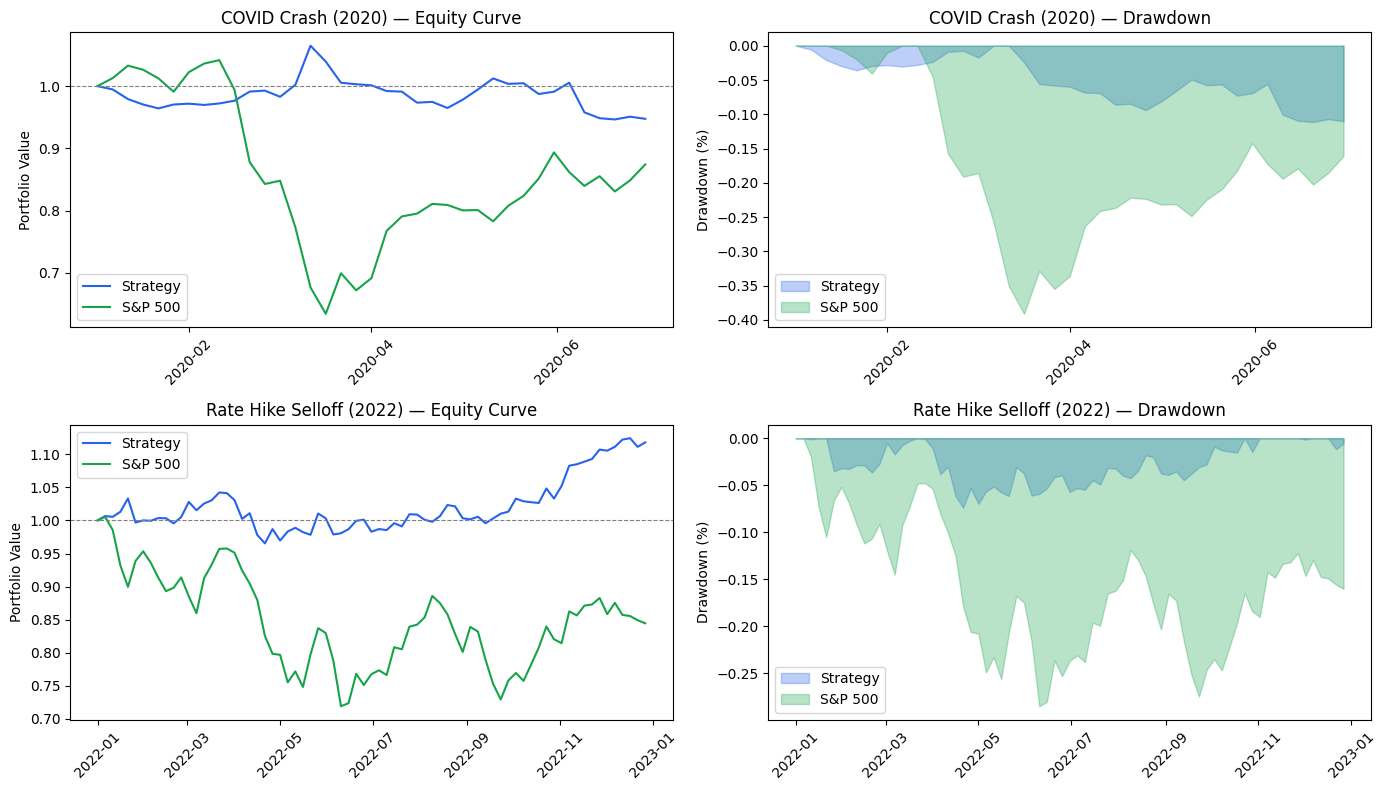

In [7]:
fig, axes = plt.subplots(len(crisis_periods), 2, figsize=(14, 8))

for idx, (name, (start, end)) in enumerate(crisis_periods.items()):
    strat = results["strategy"].loc[start:end]
    sp500 = sp500_weekly.loc[start:end]

    strat_curve = np.exp(strat.cumsum())
    sp500_curve = np.exp(sp500.cumsum())

    # normalize both to start at 1
    strat_curve = strat_curve / strat_curve.iloc[0]
    sp500_curve = sp500_curve / sp500_curve.iloc[0]

    strat_dd = (strat_curve - strat_curve.cummax()) / strat_curve.cummax()
    sp500_dd = (sp500_curve - sp500_curve.cummax()) / sp500_curve.cummax()

    # equity curve
    axes[idx, 0].plot(strat_curve.index, strat_curve.values, color="#2563eb", linewidth=1.5, label="Strategy")
    axes[idx, 0].plot(sp500_curve.index, sp500_curve.values, color="#16a34a", linewidth=1.5, label="S&P 500")
    axes[idx, 0].axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    axes[idx, 0].set_title(f"{name} — Equity Curve")
    axes[idx, 0].set_ylabel("Portfolio Value")
    axes[idx, 0].legend()
    axes[idx, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[idx, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(axes[idx, 0].xaxis.get_majorticklabels(), rotation=45)

    # drawdown
    axes[idx, 1].fill_between(strat_dd.index, strat_dd.values, 0, color="#2563eb", alpha=0.3, label="Strategy")
    axes[idx, 1].fill_between(sp500_dd.index, sp500_dd.values, 0, color="#16a34a", alpha=0.3, label="S&P 500")
    axes[idx, 1].set_title(f"{name} — Drawdown")
    axes[idx, 1].set_ylabel("Drawdown (%)")
    axes[idx, 1].legend()
    axes[idx, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[idx, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(axes[idx, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("crisis_analysis.png", dpi=150)
plt.show()

COVID crash: The S&P dropped to 0.65 at its worst (-35% drawdown) while the strategy barely moved, staying around 1.0 the whole time. Almost flat during one of the worst market crashes in recent history.
2022 rate hike selloff: Even more striking — the S&P lost ~25% at its worst while the strategy actually made money, ending the year at +13.5%. This is the best result in the whole project — the strategy didn't just resist the crisis, it profited from it.
The drawdown panels confirm it visually — the blue area is almost invisible compared to the green in both crises.